Packages
---

In [126]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import scipy.optimize as op
import ising
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata

Loading dataset
---

Loaded 300 files with their corresponding beta and h values.
First file parameters -> Beta: 0.001, H: 0.0
x_train_flat shape: (300, 40000)
y_train shape: (300,)


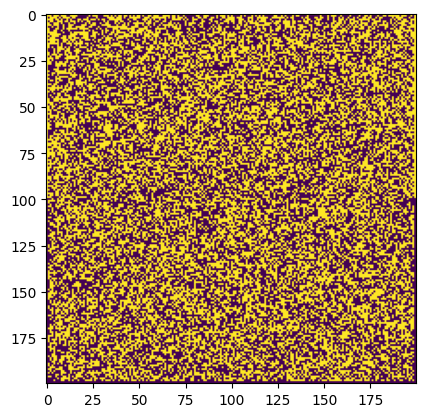

In [127]:
# Find all .npz files in the data directory
file_pattern = "../2dIsingData/zero_h/*.npz"
all_files = glob.glob(file_pattern)

dataset_list = []

for file_path in all_files:
    # 1. Strip away the folder path ("data/") and the extension (".npz")
    # Example: "data/0.44_0.0_above_2026..." -> "0.44_0.0_above_2026..."
    base_name = os.path.basename(file_path).replace(".npz", "")
    
    # 2. Split the string by underscores
    # Parts will look like: ["0.44", "0.0", "above", "20260522", "092547", "123456"]
    parts = base_name.split("_")
    
    # 3. Extract and convert beta and h from their positions in the filename
    beta_val = float(parts[0])
    h_val = float(parts[1])
    criticality = True
    if(parts[2] == "above"):
        pass
    else:
        criticality = False


    
    # 4. Load the actual arrays from inside the file
    with np.load(file_path) as data:
        dataset_list.append({
            "filename": file_path,
            "beta": beta_val,
            "h": h_val,
            "sigma": data['sigma'],
            "phase": str(data['phase']),
            "criticality": criticality
        })

print(f"Loaded {len(dataset_list)} files with their corresponding beta and h values.")

# Example: Inspecting the parameters of the first loaded file
print(f"First file parameters -> Beta: {dataset_list[0]['beta']}, H: {dataset_list[0]['h']}")

# Test
plt.imshow(dataset_list[0]['sigma'])

#Formatting for training
# 1. Extract and flatten each individual sigma matrix
# This creates a 2D array of shape (num_samples, num_features)
x_train_flat = np.array([sample['sigma'].flatten() for sample in dataset_list])

# 2. Extract the criticality booleans/labels
# This creates a 1D array of shape (num_samples,)
y_train = np.array([sample['criticality'] for sample in dataset_list])

# Verification check
print("x_train_flat shape:", x_train_flat.shape)
print("y_train shape:", y_train.shape)

Training for the case of h = 0
---

In [128]:
N = 200
INPUT_SHAPE = N * N
BATCH_SIZE = 32
EPOCHS = 25

def build_ising_model(input_dim):
    model = models.Sequential([
        # Flatten the n x n grid into a 1D vector
        layers.Input(shape=(input_dim,)),
        
        # Hidden Layer 1
        layers.Dense(64, activation='relu'),
        
        # Hidden Layer 2
        layers.Dense(32, activation='relu'),
        
        # Output Layer: Sigmoid squashes output to range [0, 1]
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_ising_model(INPUT_SHAPE)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.4
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,562,177 (9.77 MB)

 Trainable params: 2,562,177 (9.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8056 - loss: 5.1811 - val_accuracy: 0.0000e+00 - val_loss: 21.5696
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8389 - loss: 2.2412 - val_accuracy: 1.0000 - val_loss: 0.1215
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7944 - loss: 0.4968 - val_accuracy: 1.0000 - val_loss: 0.0251
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8389 - loss: 0.3706 - val_accuracy: 0.0000e+00 - val_loss: 2.8801
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9333 - loss: 0.1445 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9833 - loss: 0.0668 - val_accuracy: 1.0000 - val_loss: 0.0768
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9944 - loss: 0.0303 - val_accuracy: 1.0000 - val_loss: 0.0139
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9833 - loss: 0.0340 - val_accuracy: 1.0000 - val_loss

Visualizing the critical temperature using the model
---

In [129]:
literature_beta = 0.4407
def smooth_crit_temp(beta, a, k=50):
    return 1 / (1 + np.exp(k * (beta - a)))

def fit_critical(betas, predictions):
    plt.scatter(betas, predictions, label='Model\'s last layer', marker = '4')
    popt, pcov = op.curve_fit(smooth_crit_temp, betas, predictions.flatten(), p0=[0.4])
    plt.vlines(popt[0], 0, 1, colors='b', linestyles='dashed', label=f'Fit Critical Beta: {popt[0]:.4f}')
    plt.vlines(literature_beta, 0, 1, colors='r', linestyles='dashed', label=f'Literature Beta: {literature_beta:.4f}')
    plt.xlabel("Inverse temperature beta")
    plt.ylabel("Above critical or not")
    plt.grid(True)
    plt.legend()
    plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


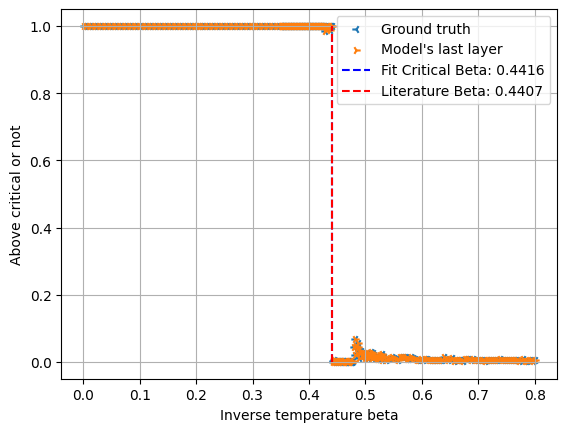

In [130]:
betas = np.array([sample['beta'] for sample in dataset_list])
criticalities = np.array([sample['criticality'] for sample in dataset_list])
predictions = model.predict(x_train_flat)

plt.scatter(betas, predictions, label='Ground truth', marker = '3')
fit_critical(betas, predictions)

Though the model saw 60% of labels for these matrices, the resulting beta is in good agreement with the value listed on wikipedia: 0.4406867

There is an interesting kink around 0.5, it may have something to do with "validation_split" taking a continuous subset of the training data instead of a random one

Fitting to subsets of spin grids, determining beta from predicting fresh data (h = 0 case)
---

In [131]:
# Define crop size
m = 150

def random_crop(matrix, size):
    h, w = matrix.shape
    # Calculate the maximum valid starting indices to prevent out-of-bounds errors
    max_h = h - size
    max_w = w - size
    
    # Pick random starting coordinates
    start_h = np.random.randint(0, max_h + 1)
    start_w = np.random.randint(0, max_w + 1)
    
    return matrix[start_h : start_h + size, start_w : start_w + size]

# Find all .npz files in the data directory
file_pattern = "../2dIsingData/zero_h/*.npz"
all_files = glob.glob(file_pattern)

dataset_list = []

for file_path in all_files:
    # 1. Strip away the folder path ("data/") and the extension (".npz")
    base_name = os.path.basename(file_path).replace(".npz", "")
    
    # 2. Split the string by underscores
    parts = base_name.split("_")
    
    # 3. Extract and convert beta and h from their positions in the filename
    beta_val = float(parts[0])
    h_val = float(parts[1])
    criticality = True
    if(parts[2] == "above"):
        pass
    else:
        criticality = False

    # 4. Load the actual arrays from inside the file
    with np.load(file_path) as data:
        dataset_list.append({
            "filename": file_path,
            "beta": beta_val,
            "h": h_val,
            "sigma": data['sigma'],
            "phase": str(data['phase']),
            "criticality": criticality
        })
# Formatting for training

x_train_flat = np.array([random_crop(sample['sigma'], m).flatten() for sample in dataset_list])
y_train = np.array([sample['criticality'] for sample in dataset_list])
betas = np.array([sample['beta'] for sample in dataset_list])

#Fit the model to the unforgiving data
model = build_ising_model(m*m)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0 #We will be doing ample validation with a separate dataset
)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │     1,440,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,442,177 (5.50 MB)

 Trainable params: 1,442,177 (5.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5633 - loss: 2.3355
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8133 - loss: 0.7842
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8633 - loss: 0.3519
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9467 - loss: 0.1574
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9900 - loss: 0.0680
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9900 - loss: 0.0426
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9967 - loss: 0.0192
Epoch 8/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9967 - loss: 0.0144
Epoch 9/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0093
Epoch 10/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0072
Epoch 11/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0062
Epoch 12/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy:

In [132]:
#As convergence indeed slows with decreasing m, we generate supplementary data to predict on
new_betas = np.linspace(0, 1, 100)
x_train_flat_new = 0
for beta in new_betas:
    generator = ising.Ising(0, beta, N)
    generator.generate()
    if(beta == 0):
        x_train_flat_new = random_crop(generator.sigma, m).flatten()
    else:
        x_train_flat_new = np.column_stack((x_train_flat_new, random_crop(generator.sigma, m).flatten()))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


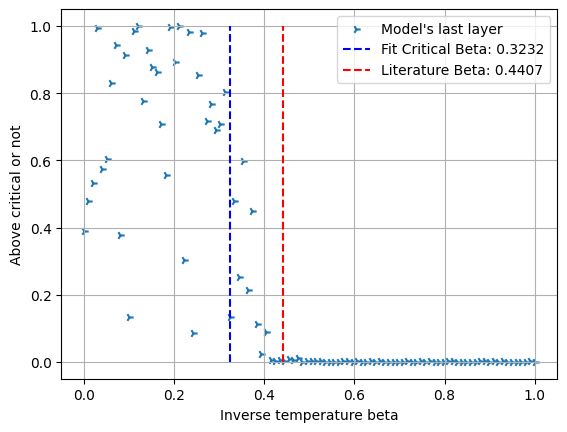

In [133]:
x_train_flat_new = x_train_flat_new.T
predictions = model.predict(x_train_flat_new)

fit_critical(new_betas, predictions.flatten())

The result of predicting on fresh, randomly positioned subsets is weak. This could indicate that the model was relying on features belonging to certain weights, such as the middle boundary, or the frame always being in the same place. Interestingly subcritical recognition wasn't hurt nearly as much as supercritical, but its interval also starts expanding upwards.

Throwing parameters at the problem
---

In [134]:
EPOCHS = 10
def build_ising_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(int(input_dim/2), activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_ising_model(m*m)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.05
)

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 11250)          │   253,136,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │       720,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,858,427 (968.39 MB)

 Trainable params: 253,858,427 (968.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6386 - loss: 15.4119 - val_accuracy: 1.0000 - val_loss: 7.6605e-23
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7509 - loss: 3.5914 - val_accuracy: 1.0000 - val_loss: 1.7546e-14
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9018 - loss: 0.6117 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9719 - loss: 0.0766 - val_accuracy: 0.8667 - val_loss: 0.1920
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9789 - loss: 0.0581 - val_accuracy: 0.6000 - val_loss: 0.5883
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9789 - loss: 0.0447 - val_accuracy: 0.6667 - val_loss: 1.3643
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9474 - loss: 0.1922 - val_accuracy: 1.0000 - val_loss: 2.0793e-17
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8877 - loss: 1.5526 - val_accuracy: 1.0000 - val_loss: 7.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


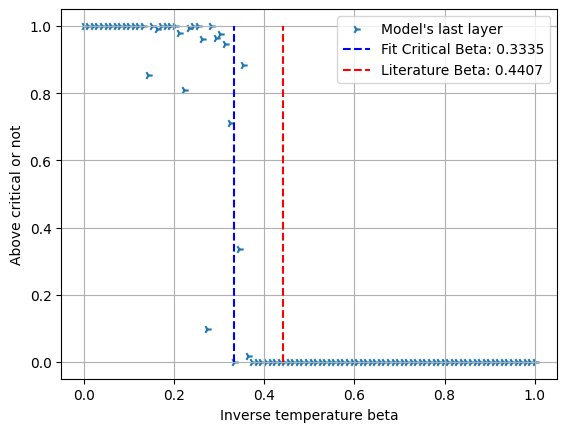

In [135]:
x_train_flat_new = 0
#Excuse the ugly condition and loop...
for beta in new_betas:
    generator = ising.Ising(0, beta, N)
    generator.generate()
    if(beta == 0):
        x_train_flat_new = random_crop(generator.sigma, m).flatten()
    else:
        x_train_flat_new = np.column_stack((x_train_flat_new, random_crop(generator.sigma, m).flatten()))

x_train_flat_new = x_train_flat_new.T
predictions = model.predict(x_train_flat_new)

fit_critical(new_betas, predictions.flatten())

Note, the model doesn't appear to converge every time, please run untill step function appears with shifted phase-transition

The model with dramatically more parameters remarkably appears to converge to the same place as did the smaller one. The perceived phase transition is shifted to a higher temperature. This result can be interpreted as the submatrices containing less total structure due to their inherently decreased size, this appears as increased disorder/temperature, and the model is therefore confidently wrong. Though the phase transition appears to be only measurable on complete spin grids, we did succeed in having the FCNN learn patterns that were not related to the position of weights in relation to the data, but their relation.
This discussion was influenced by Gemini, which can be read through the following link: [text](https://gemini.google.com/share/c3af6818e43d)

Case of external magnetic field h
---

In [136]:
#Separating dataset
def separate_files(file_pattern):
    #Reading labels from the file names
    all_files = glob.glob(file_pattern)
    phases = []
    for file_path in all_files:
        basename = os.path.basename(file_path)
        name_without_ext = os.path.splitext(basename)[0]
        tokens = name_without_ext.split('_')
        phases.append(1 if tokens[2] == 'above' else 0)
     
    list_train, list_test = train_test_split(
    all_files, test_size=0.20, stratify=phases, random_state=42
    )
    return list_train, list_test

def read_file_parameters(file_path):
    basename = os.path.basename(file_path)
    name_without_ext = os.path.splitext(basename)[0]
    tokens = name_without_ext.split('_')

    beta  = float(tokens[0])
    h = float(tokens[1])
    phase = 1 if tokens[2] == 'above' else 0
    
    return beta, h, phase

def load_directory(file_pattern):
    list_train, list_test = separate_files(file_pattern)

    parameters_train = [read_file_parameters(file_path) for file_path in list_train]
    parameters_test = [read_file_parameters(file_path) for file_path in list_test]

    betas_train, hs_train, phases_train = np.array(parameters_train).T
    betas_test, hs_test, phases_test = np.array(parameters_test).T
    #With this we now have an array of each parameter and a list of files separated
    #into train and test sets

    return (list_train, betas_train, hs_train, phases_train,
            list_test, betas_test, hs_test, phases_test)

(list_train, betas_train, hs_train, phases_train,
 list_test, betas_test, hs_test, phases_test) = load_directory("../2dIsingData/non_zero_h/*.npz")

#A bit roundabout, but was necessary in order for homogeneous sampling of betas across datasets

In [146]:
#Compiling model
N = 200
INPUT_DIM = N * N
BATCH_SIZE = 16
EPOCHS = 10
model = models.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

def train_by_batch(model, BATCH_SIZE, EPOCHS, list_train, phases_train):

    #Training by batches, will be preferable for the large dataset
    num_samples = len(list_train)

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        
        # Iterate through the dataset in chunks of BATCH_SIZE
        for i in range(0, num_samples, BATCH_SIZE):
            
            # Determine the slice of files and labels for this specific batch
            batch_files = list_train[i : i + BATCH_SIZE]
            batch_labels = phases_train[i : i + BATCH_SIZE]
            
            batch_features = []
            # Load only the required sigma matrices into RAM
            for file_path in batch_files:
                with np.load(file_path) as data:
                    matrix = data['sigma'].copy()
                    batch_features.append(matrix)
            
            # Convert lists to standard NumPy arrays for the model
            X_batch = np.array(batch_features).reshape(len(batch_files), -1)
            y_batch = np.array(batch_labels)
            
            # Train the model on this single batch and discard it immediately after
            metrics = model.train_on_batch(X_batch, y_batch)

        print(f"Loss: {metrics[0]:.4f} - Accuracy: {metrics[1]:.4f}")
#Training
train_by_batch(model, BATCH_SIZE, EPOCHS, list_train, phases_train)


Epoch 1/10
Loss: 0.6583 - Accuracy: 0.7523

Epoch 2/10
Loss: 0.4952 - Accuracy: 0.7983

Epoch 3/10
Loss: 0.4275 - Accuracy: 0.8204

Epoch 4/10
Loss: 0.3832 - Accuracy: 0.8371

Epoch 5/10
Loss: 0.3508 - Accuracy: 0.8494

Epoch 6/10
Loss: 0.3270 - Accuracy: 0.8592

Epoch 7/10
Loss: 0.3112 - Accuracy: 0.8655

Epoch 8/10
Loss: 0.3014 - Accuracy: 0.8701

Epoch 9/10
Loss: 0.2896 - Accuracy: 0.8751

Epoch 10/10
Loss: 0.2780 - Accuracy: 0.8800


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


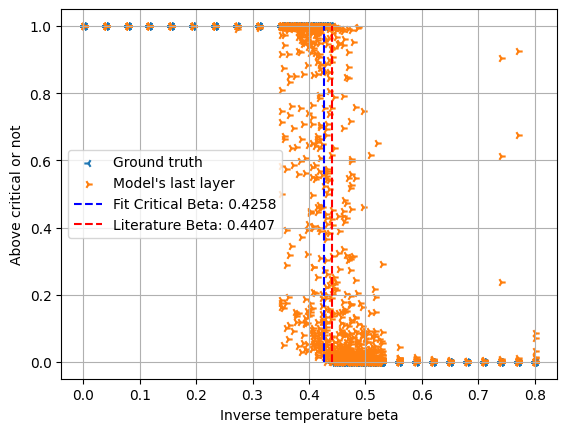

In [147]:
#Assembling test vector
X_test = []
for file_path in list_test:
    with np.load(file_path) as data:
        matrix = data['sigma'].copy()
        X_test.append(matrix)
X_test = np.array(X_test).reshape((len(list_test), -1))
predictions = model.predict(X_test)

plt.scatter(betas_test, phases_test, label='Ground truth', marker = '3')
fit_critical(betas_test, predictions)

There is considerable spread around T_c thanks to h being non zero, but the fit avarages to a value close to the literature value.

Let's see it in 3D

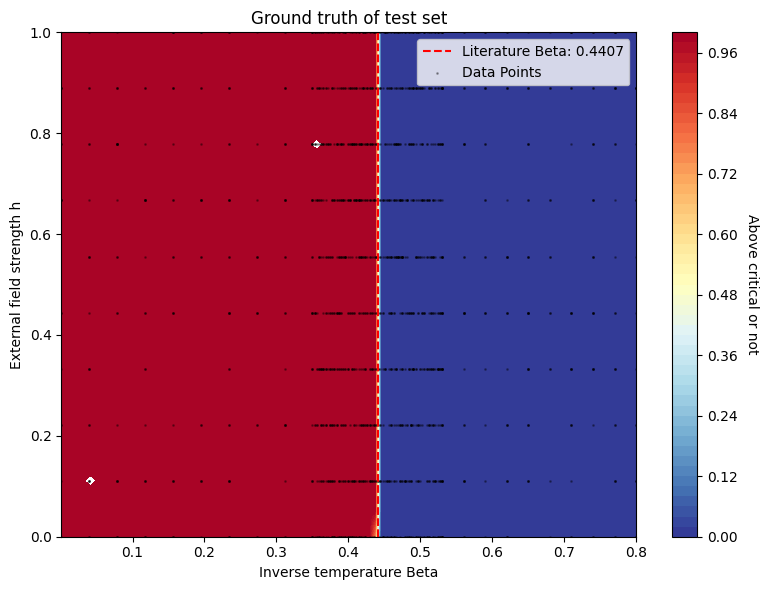

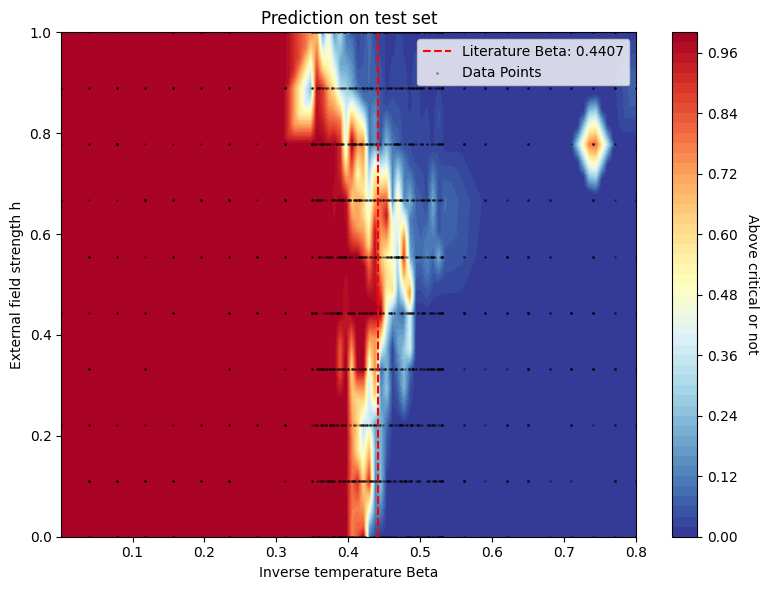

In [148]:
def plot_3D(z, title):
    # 1. Ensure inputs are flat 1D arrays of shape (1600,)
    x_clean = betas_test.ravel()
    y_clean = hs_test.ravel()
    z_clean = z.ravel()

    # 2. Create a dense regular 2D grid
    x_grid = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_grid = np.linspace(y_clean.min(), y_clean.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)

    # 3. Interpolate the data
    Z = griddata((x_clean, y_clean), z_clean, (X, Y), method='linear')

    # 4. Force Z to be 2D by removing any singleton dimensions (e.g., shape (100, 100, 1) -> (100, 100))
    Z = Z.squeeze()

    # 5. Plot using contourf
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=50, cmap='RdYlBu_r', vmin=0, vmax=1)

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Above critical or not', rotation=270, labelpad=15)
    plt.vlines(literature_beta, 0, 1, colors='r', linestyles='dashed', label=f'Literature Beta: {literature_beta:.4f}')

    ax.scatter(betas_test, hs_test, c='black', s=1, alpha=0.3, label='Data Points')

    ax.set_xlabel('Inverse temperature Beta')
    ax.set_ylabel('External field strength h')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()

plot_3D(phases_test, "Ground truth of test set")
plot_3D(predictions, "Prediction on test set")

Note: Though "duplicate" datapoints technically are not accounted for, but they don't make a difference in practice.

There doesn't appear to be a single trend in the error the model makes, the field having been exclusively positive in the training set might be an issue.

We operated under the assumption that phase change would happen at T_c regardless of h (see first plot), this might not be true.